1. import dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import os

# 1. Mount Google Drive (tempat menyimpan agregasi bulan pertama)
from google.colab import drive
drive.mount('/content/drive')

DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. baca dan olah dataset bulan baru

In [7]:
agregasi_januari = pd.read_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv")

3. Gabungkan dengan data bulan praktikum (misal Januari 2023) untuk Tabel Perbandingan

In [8]:
URL_JULI = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH_JULI = "yellow_tripdata_2023-07.parquet"

if not os.path.exists(PATH_JULI):
    urllib.request.urlretrieve(URL_JULI, PATH_JULI)

df_juli = pd.read_parquet(PATH_JULI, columns=["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "total_amount"])
df_juli["durasi_menit"] = (df_juli["tpep_dropoff_datetime"] - df_juli["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Filtering data anomali
df_juli_bersih = df_juli[
    (df_juli["trip_distance"] > 0) & (df_juli["trip_distance"] < 100) &
    (df_juli["durasi_menit"] >= 1) & (df_juli["durasi_menit"] <= 180) &
    (df_juli["total_amount"] > 0)
].copy()

df_juli_bersih["jam"] = df_juli_bersih["tpep_pickup_datetime"].dt.hour
agregasi_juli = df_juli_bersih.groupby("jam").size().reset_index(name="jumlah_juli_2023")

4. gabungkan untuk tabel perbandingan

In [9]:
tabel_komparasi = pd.merge(
    agregasi_januari[["jam", "jumlah_perjalanan"]],
    agregasi_juli,
    on="jam"
)
tabel_komparasi.columns = ["jam", "jumlah_januari_2023", "jumlah_juli_2023"]

print("=== TABEL PERBANDINGAN POLA PER JAM ===")
print(tabel_komparasi)

=== TABEL PERBANDINGAN POLA PER JAM ===
    jam  jumlah_januari_2023  jumlah_juli_2023
0     0                82289             85987
1     1                57766             59980
2     2                40445             40812
3     3                26146             26000
4     4                16618             16637
5     5                16940             16913
6     6                42300             38422
7     7                84569             69358
8     8               114064            103647
9     9               127988            118788
10   10               140230            130529
11   11               150539            143780
12   12               165714            157384
13   13               174183            161822
14   14               186741            169475
15   15               191392            172601
16   16               190689            173983
17   17               204399            186220
18   18               210858            195988
19   19             

5. visualisasi

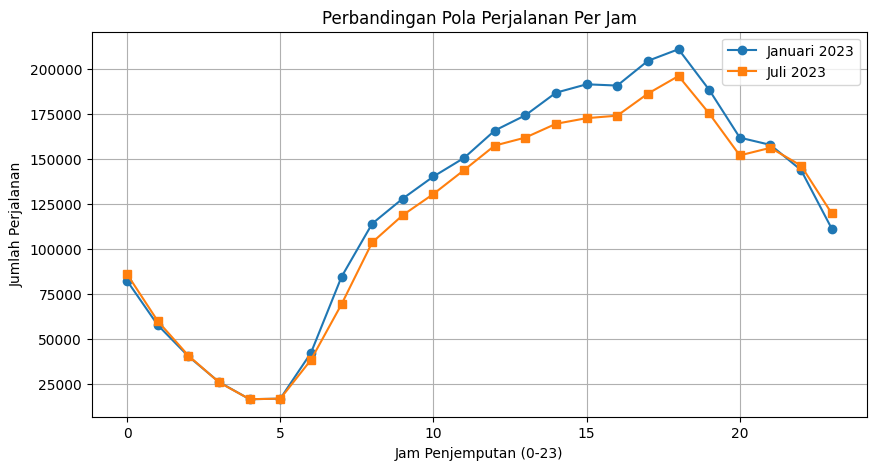

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(tabel_komparasi["jam"], tabel_komparasi["jumlah_januari_2023"], marker='o', label="Januari 2023")
plt.plot(tabel_komparasi["jam"], tabel_komparasi["jumlah_juli_2023"], marker='s', label="Juli 2023")
plt.title("Perbandingan Pola Perjalanan Per Jam")
plt.xlabel("Jam Penjemputan (0-23)")
plt.ylabel("Jumlah Perjalanan")
plt.grid(True)
plt.legend()
plt.savefig(f"{DIR_SIMPAN}/perbandingan_bulan.png")
plt.show()

**1 dan 2:komparasi dataset perjalanan taksi (januari vs juli 2023**

Pemrosesan dataset NYC TLC Yellow Taxi untuk bulan Januari 2023 dan Juli 2023 menunjukkan pola agregasi harian yang sangat serupa secara umum. Berdasarkan tabel agregasi dan grafik perbandingan yang dihasilkan, kedua bulan tersebut memiliki kurva distribusi perjalanan harian dengan titik terendah terjadi pada dini hari sekitar pukul 04.00 hingga 05.00 WIB. Setelah melewati titik terendah tersebut, volume penumpang mengalami lonjakan drastis mulai pukul 06.00 WIB seiring dimulainya jam aktivitas masyarakat, lalu terus meningkat secara konsisten hingga mencapai puncak aktivitas harian (peak hour) pada pukul 18.00 WIB. Perbedaan utama di antara kedua periode ini terletak pada volume perjalanan total, di mana bulan Januari 2023 secara konsisten mencatatkan jumlah perjalanan yang lebih tinggi dibandingkan bulan Juli 2023, khususnya pada rentang jam sibuk siang hingga sore hari (pukul 08.00 hingga 19.00 WIB).

**3. laporan kinerja pemrosesan data**

Berdasarkan pencatatan waktu pada berkas pengukuran_kinerja.csv, tahap pemrosesan yang membutuhkan alokasi waktu dan sumber daya komputasi paling mahal adalah operasi I/O saat pembacaan serta penulisan file mentah berformat CSV. Format CSV menyimpan data dalam bentuk teks mentah tanpa kompresi, sehingga sistem harus melakukan proses parsing string untuk setiap baris dan kolom yang membutuhkan daya komputasi CPU dan alokasi RAM yang cukup besar. Perubahan konkret yang diusulkan untuk mempercepat kinerja alur data adalah beralih dari format CSV ke format biner berbasis kolom seperti Parquet untuk seluruh tahapan intermediate. Penggunaan Parquet yang dikombinasikan dengan teknik column pruning (hanya membaca kolom yang diperlukan dalam kueri) terbukti mampu mengurangi ukuran penyimpanan berkas hingga lebih dari 70% serta memangkas latensi waktu pembacaan data secara signifikan.

**4. refleksi teori dimensi 5v pada dataset praktikum**

Dalam konteks arsitektur Big Data, dataset perjalanan taksi ini tergolong "big" terutama pada dimensi Volume dan Veracity untuk skala pemrosesan pada satu mesin lokal atau lingkungan komputasi awan seperti Google Colab. Dimensi Volume terlihat dari jumlah baris data yang mencapai lebih dari 3,06 juta baris dalam satu bulan, yang langsung berdampak pada konsumsi memori RAM yang besar saat dimuat secara penuh. Sementara itu, dimensi Veracity menonjol karena tingginya tingkat anomali pada data mentah, seperti adanya nilai jarak perjalanan nol atau negatif, durasi perjalanan di luar batas wajar, serta total biaya bernilai negatif yang memerlukan pembersihan eksplisit. Sebaliknya, dataset ini sebenarnya tidak tergolong "big" pada dimensi Velocity dan Variety. Hal ini dikarenakan pengolahan data dilakukan secara batch berbasis berkas statis bulanan (bukan data streaming real-time per milidetik), serta memiliki struktur data tabel yang sudah sangat teratur dan konsisten tanpa adanya data tidak terstruktur seperti teks bebas atau media.

**5. keandalasn dan reproduksibilitas kode**

Seluruh blok kode di dalam notebook ini dirancang agar dapat dieksekusi dari awal hingga akhir secara otomatis dalam lingkungan runtime baru yang bersih (Runtime -> Restart and run all). Seluruh pustaka eksternal yang dibutuhkan diisolasi di sel awal, serta penanganan berkas menggunakan alur unduhan otomatis dan pengaitan ke Google Drive agar tidak bergantung pada penyimpanan sementar lingkungan Colab yang bersifat efemeral. Dengan desain ini, alur analisis, pengolahan data, hingga ekstraksi grafik hasil dapat direplikasi secara konsisten tanpa memerlukan intervensi manual tambahan.